In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski
import bm3d
import importlib
import os
import optics as op
import seaborn as sns
from read_mrc import read_mrc

In [10]:
# Load the clean reference image
_, sim_gt = read_mrc('..//BioTISR//BioTISR_Microtubules//Cell_001//SIM_gt.mrc')
sim_gt[sim_gt < 0] = 0
sim_gt = op.normalize(sim_gt)
sim_gt = sim_gt.transpose(2, 0, 1)
sim_gt = np.rot90(sim_gt, k=1, axes=(1, 2))

sim_unfiltered = ski.io.imread('..//BioTISR//BioTISR_Microtubules//Cell_001//SIM_unfiltered.tif')
sim_unfiltered[sim_unfiltered < 0] = 0
sim_unfiltered = op.normalize(sim_unfiltered)

sim_filtered = ski.io.imread('..//BioTISR//BioTISR_Microtubules//Cell_001//SIM_filtered.tif')
sim_filtered[sim_filtered < 0] = 0
sim_filtered = op.normalize(sim_filtered)

metric = sim_gt

# sim_filtered = np.concatenate([sim_unfiltered]*4, axis=0)
print(np.min(sim_filtered), np.max(sim_filtered),np.shape(sim_filtered))

filter_names = ['noisy', 'wiener', 'tv', 'bm3d', 'rl']
print(np.min(metric), np.max(metric), np.shape(sim_gt))


0.0 1.0 (100, 1024, 1024)
0.0 1.0 (20, 1024, 1024)


In [11]:

# Data storage
results = []

# Calculate PSNR and SSIM for each filter and each image
for filter_idx, filter_name in enumerate(filter_names):
    for img_idx in range(20):
        psnr_value = ski.metrics.peak_signal_noise_ratio(metric[img_idx], sim_filtered[filter_idx * 20 + img_idx])
        ssim_value = ski.metrics.structural_similarity(metric[img_idx], sim_filtered[filter_idx * 20 + img_idx], data_range=1)
        results.append([filter_name, img_idx, psnr_value, ssim_value])

# Create a DataFrame to store the results
df = pd.DataFrame(results, columns=['Filter', 'Image_Index', 'PSNR', 'SSIM'])
display(df)


C:\Users\itsak\AppData\Local\Temp\ipykernel_15572\3541903527.py:7: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr_value = ski.metrics.peak_signal_noise_ratio(metric[img_idx], sim_filtered[filter_idx * 20 + img_idx])


,Filter,Image_Index,PSNR,SSIM
0,noisy,0,23.214430,0.554544
1,noisy,1,23.138105,0.575354
2,noisy,2,23.223419,0.575966
3,noisy,3,23.440734,0.579767
4,noisy,4,22.590671,0.556676
...,...,...,...,...
95,rl,15,23.146857,0.546557
96,rl,16,22.256004,0.515958
97,rl,17,23.969849,0.567250
98,rl,18,22.753778,0.528872


PSNR                SSIM          
             mean       std      mean       std
Filter                                         
noisy   22.967000  0.714632  0.553344  0.029196
wiener  23.443938  0.756872  0.567269  0.031150
tv      22.966998  0.714632  0.553344  0.029196
bm3d    22.967019  0.714696  0.553402  0.029185
rl      23.443945  0.756870  0.567268  0.031151

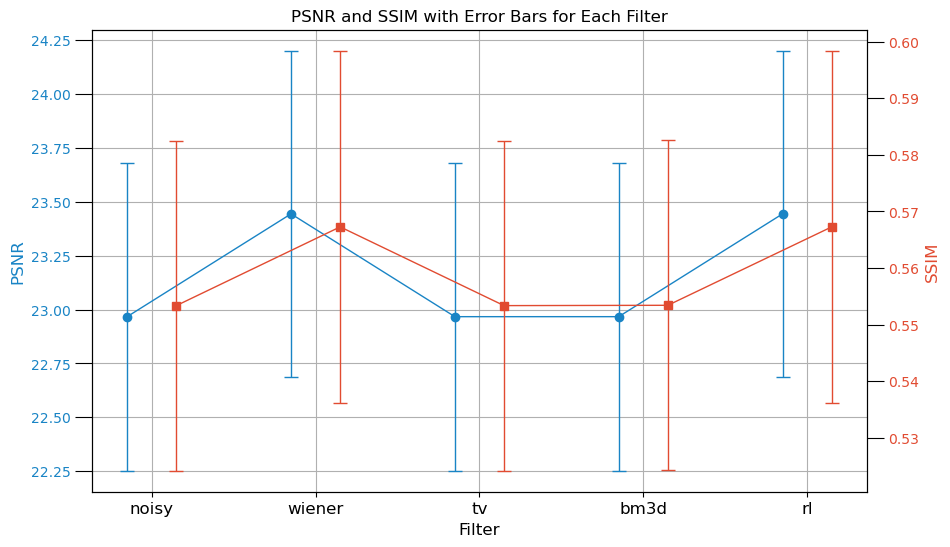

In [12]:
# Group data by filter and calculate mean and standard deviation for PSNR and SSIM
grouped = df.groupby('Filter', sort=False).agg({'PSNR': ['mean', 'std'], 'SSIM': ['mean', 'std']})
display(grouped)

# Extract values for plotting
filters = grouped.index
psnr_means = grouped['PSNR']['mean']
psnr_stds = grouped['PSNR']['std']
ssim_means = grouped['SSIM']['mean']
ssim_stds = grouped['SSIM']['std']

filters = grouped.index
x = np.arange(len(filters))  # Numeric positions for x-axis

# Offsets to separate error bars slightly
offset = 0.15

psnr_color = "#1984c5"
ssim_color = "#e14b31"
# psnr_color = "C0"
# ssim_color = "C1"


fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot PSNR with error bars (shifted left)
ax1.errorbar(x - offset, psnr_means, yerr=psnr_stds, fmt='o-', label='PSNR', color=psnr_color, linewidth=1, capsize=5)
# ax1.fill_between(x - offset, psnr_means-psnr_stds, psnr_means+psnr_stds, color=psnr_color, alpha=0.2)
ax1.set_xlabel('Filter', fontsize=12)
ax1.set_ylabel('PSNR', color=psnr_color, fontsize=12)
# ax1.set_ylim([20, 25])
ax1.tick_params(axis='y', labelcolor=psnr_color, size=12)

# Create a second y-axis for SSIM
ax2 = ax1.twinx()

# Plot SSIM with error bars (shifted right)
ax2.errorbar(x + offset, ssim_means, yerr=ssim_stds, fmt='s-', label='SSIM', color=ssim_color, linewidth=1, capsize=5)
# ax2.fill_between(x + offset, ssim_means-ssim_stds, ssim_means+ssim_stds, color=ssim_color, alpha=0.2)
ax2.set_ylabel('SSIM', color=ssim_color, fontsize=12)
# ax2.set_ylim([0.5, 0.7])
ax2.tick_params(axis='y', labelcolor=ssim_color, size=12)

# Set x-axis tick labels
ax1.set_xticks(x)
ax1.set_xticklabels(filters, fontsize=12)

# Title and grid
plt.title('PSNR and SSIM with Error Bars for Each Filter', fontsize=12)
ax1.grid(True)

# plt.tight_layout()
plt.show()